In [21]:

# CardioGuard -- Modeling

# Goal:
# Build a supervised ML model to predict high cardiometabolic risk.
# Target: high_risk_flag
# Approach:
# 1. Load feature-engineered dataset
# 2. Select features
# 3. Train/test split
# 4. Build preprocessing + model pipelines
# 5. Compare Logistic Regression, Random Forest, XGBoost
# 6. Tune threshold
# 7. Save best model

### STEP 1 - Setup & Imports

In [2]:

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid", font_scale=1.1)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Define Paths

DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")

os.makedirs(MODEL_DIR, exist_ok=True)

### STEP 2 - Load Feature Dataset

In [3]:
df = pd.read_csv(
    os.path.join(DATA_PROCESSED, "cardioguard_model_features.csv")
)

print(df.shape)
df.head()

(9254, 33)


,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,age_65_plus_flag,low_income_flag,low_education_flag,bmi,...,hdl_cholesterol,ldl_cholesterol,triglycerides,tc_hdl_ratio,ldl_hdl_ratio,trig_hdl_ratio,smoker_flag,physically_active_flag,inactive_flag,high_risk_flag
0,93703.0,2.0,Female,Non-Hispanic Asian,NaN,5.00,0,0,0,17.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,93704.0,2.0,Male,Non-Hispanic White,NaN,5.00,0,0,0,15.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,93705.0,66.0,Female,Non-Hispanic Black,9th-11th grade,0.82,1,1,1,31.7,...,60.0,NaN,NaN,2.616667,NaN,NaN,1.0,1.0,0.0,0
3,93706.0,18.0,Male,Non-Hispanic Asian,NaN,NaN,0,0,0,21.5,...,47.0,NaN,NaN,3.148936,NaN,NaN,0.0,1.0,0.0,0
4,93707.0,13.0,Male,Other Race,NaN,1.88,0,0,0,18.1,...,68.0,NaN,NaN,2.779412,NaN,NaN,0.0,0.0,1.0,0


### STEP 4 - Define Target

- high_risk_flag is the target variable.

- 1 = High cardiometabolic risk
- 0 = Not high risk

In [4]:
TARGET = "high_risk_flag"

df[TARGET].value_counts(normalize=True).mul(100).round(2)

high_risk_flag
0    86.49
1    13.51
Name: proportion, dtype: float64

### STEP 5 - Select Feature Columns

In [5]:
EXCLUDE = [
    "participant_id",
    "high_risk_flag"
]

FEATURE_COLS = [
    col for col in df.columns
    if col not in EXCLUDE
]

print(f"{len(FEATURE_COLS)} features selected")
print(FEATURE_COLS)

31 features selected
['age', 'gender', 'ethnicity', 'education_level', 'poverty_income_ratio', 'age_65_plus_flag', 'low_income_flag', 'low_education_flag', 'bmi', 'waist_circumference', 'weight', 'height', 'waist_to_height_ratio', 'bmi_to_waist_ratio', 'systolic_bp', 'diastolic_bp', 'pulse_pressure', 'mean_arterial_pressure', 'fasting_glucose', 'hba1c', 'glucose_hba1c_ratio', 'total_cholesterol', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'tc_hdl_ratio', 'ldl_hdl_ratio', 'trig_hdl_ratio', 'smoker_flag', 'physically_active_flag', 'inactive_flag']


### STEP 6 - Create X and y

In [6]:
X = df[FEATURE_COLS]
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9254, 31)
y shape: (9254,)


### STEP 7 - Identify Numeric and Categorical Columns


In [7]:
# We separate numeric and categorical columns because they need different preprocessing:

# Numeric columns → median imputation + scaling
# Categorical columns → most frequent imputation + one-hot encoding


numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 28
Categorical features: 3
['gender', 'ethnicity', 'education_level']


### STEP 8 - Train/Test Split

In [8]:
# stratified split so the high-risk proportion is similar in both train and test sets.

# This prevents the test set from having a very different target distribution.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target rate:", y_train.mean().round(3))
print("Test target rate:", y_test.mean().round(3))

Train shape: (7403, 31)
Test shape: (1851, 31)
Train target rate: 0.135
Test target rate: 0.135


### STEP 9 - Build Preprocessing Pipeline

In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### STEP 10 - Define Models


In [10]:

scale_pos_weight = (
    y_train.value_counts()[0] / y_train.value_counts()[1]
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    )
}

### STEP 11 - Train and Evaluate Models

In [11]:
results = []

trained_models = {}

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "model": name,
        "roc_auc": auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy
    })

    trained_models[name] = pipe

    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      1601
           1       0.50      0.89      0.64       250

    accuracy                           0.86      1851
   macro avg       0.74      0.87      0.78      1851
weighted avg       0.91      0.86      0.88      1851


Random Forest
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1601
           1       0.68      0.92      0.78       250

    accuracy                           0.93      1851
   macro avg       0.83      0.92      0.87      1851
weighted avg       0.94      0.93      0.93      1851


XGBoost
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1601
           1       0.78      0.93      0.85       250

    accuracy                           0.96      1851
   macro avg       0.88      0.95      0.91      1851
weighted avg       0.96      

### STEP 12 - Compare Model Performance
- We compare models using:

- ROC-AUC
- PR-AUC
- F1
- Precision
- Recall
- Accuracy

In [12]:
results_df = pd.DataFrame(results).sort_values(
    by="roc_auc",
    ascending=False
)

results_df

,model,roc_auc,pr_auc,f1,precision,recall,accuracy
2,XGBoost,0.989229,0.942954,0.848816,0.779264,0.932,0.955159
1,Random Forest,0.978638,0.887240,0.778912,0.677515,0.916,0.929768
0,Logistic Regression,0.942311,0.698460,0.636103,0.495536,0.888,0.862777


### STEP 13 - Select Best Model

In [13]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print(f"Best model: {best_model_name}")

Best model: XGBoost


### STEP 14 - ROC Curve

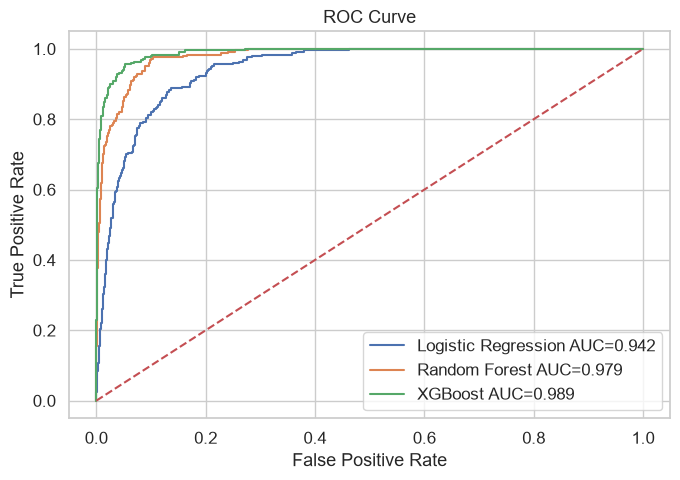

In [14]:
plt.figure(figsize=(7, 5))

for name, model in trained_models.items():

    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    auc = roc_auc_score(y_test, y_proba)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc:.3f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

### STEP 15 - Precision-Recall Curve


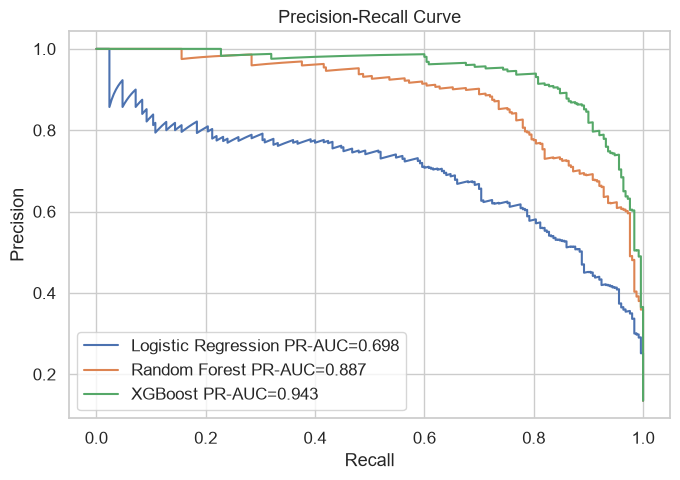

In [15]:
plt.figure(figsize=(7, 5))

for name, model in trained_models.items():

    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    pr_auc = average_precision_score(y_test, y_proba)

    plt.plot(
        recall,
        precision,
        label=f"{name} PR-AUC={pr_auc:.3f}"
    )

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

### STEP 16 - Threshold Tuning

In [16]:
# The default threshold is 0.40.

# Threshold tuning helps balance:

# Recall: catching high-risk participants
# Precision: avoiding too many false alarms

y_proba = best_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_proba
)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions[:-1],
    "recall": recalls[:-1]
})

threshold_df["f1"] = (
    2 * threshold_df["precision"] * threshold_df["recall"]
) / (
    threshold_df["precision"] + threshold_df["recall"] + 1e-9
)

threshold_df.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1
1503,0.652123,0.861004,0.892,0.876228
1521,0.720301,0.892116,0.860,0.875764
1505,0.655490,0.863813,0.888,0.875740
1502,0.651876,0.857692,0.892,0.874510
1527,0.740930,0.902128,0.848,0.874227
1504,0.655174,0.860465,0.888,0.874016
1520,0.714471,0.888430,0.860,0.873984
1529,0.744081,0.905579,0.844,0.873706
1506,0.655622,0.863281,0.884,0.873518
1522,0.722957,0.891667,0.856,0.873469


### STEP 17 - Choose Best Threshold

In [17]:
best_threshold = threshold_df.sort_values(
    "f1",
    ascending=False
).iloc[0]["threshold"]

print(f"Best threshold: {best_threshold:.3f}")

Best threshold: 0.652


# STEP 18 - Evaluate Best Model at Tuned Threshold

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1601
           1       0.86      0.89      0.88       250

    accuracy                           0.97      1851
   macro avg       0.92      0.93      0.93      1851
weighted avg       0.97      0.97      0.97      1851



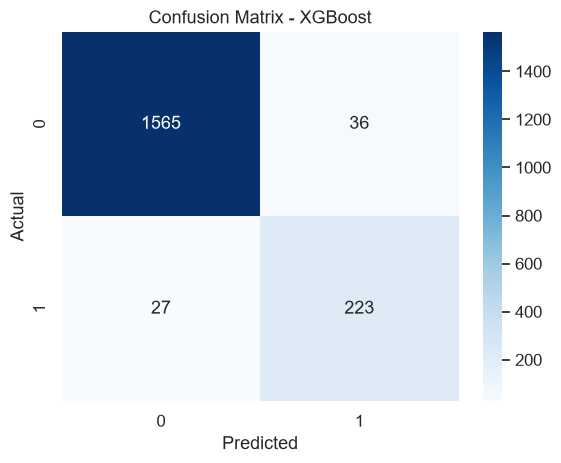

In [18]:

y_pred_tuned = (
    y_proba >= best_threshold
).astype(int)

print(classification_report(y_test, y_pred_tuned))

cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### STEP 19 - Risk Bands

In [19]:
# Instead of only predicting 0 or 1, we create risk bands:

# Low Risk:      < 40%
# Moderate Risk: 40% - 70%
# High Risk:     > 70%

# This is more useful for prevention planning.




test_results = X_test.copy()

test_results["actual_high_risk"] = y_test.values
test_results["risk_probability"] = y_proba

test_results["predicted_risk_band"] = pd.cut(
    test_results["risk_probability"],
    bins=[-0.01, 0.40, 0.70, 1.00],
    labels=["Low Risk", "Moderate Risk", "High Risk"]
)

test_results[
    [
        "actual_high_risk",
        "risk_probability",
        "predicted_risk_band"
    ]
].head()

,actual_high_risk,risk_probability,predicted_risk_band
9209,0,0.000879,Low Risk
4177,0,0.000340,Low Risk
6308,0,0.000164,Low Risk
8357,0,0.001630,Low Risk
236,0,0.001688,Low Risk


### STEP 20 - Save Model Artifacts


In [20]:

joblib.dump(
    best_model,
    os.path.join(MODEL_DIR, "cardioguard_best_model.pkl")
)

joblib.dump(
    FEATURE_COLS,
    os.path.join(MODEL_DIR, "cardioguard_feature_cols.pkl")
)

joblib.dump(
    best_threshold,
    os.path.join(MODEL_DIR, "cardioguard_best_threshold.pkl")
)

results_df.to_csv(
    os.path.join(DATA_PROCESSED, "cardioguard_model_results.csv"),
    index=False
)

print("Saved best model, feature columns, threshold, and model results.")

Saved best model, feature columns, threshold, and model results.
